Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned_ecommerce.csv")

In [3]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,year,month,day,hour
0,2019-11-01 00:00:00+00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33,2019,11,1,0
1,2019-11-01 00:00:00+00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283,2019,11,1,0
2,2019-11-01 00:00:01+00:00,view,17302664,2053013553853497655,Unknown,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387,2019,11,1,0
3,2019-11-01 00:00:01+00:00,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f,2019,11,1,0
4,2019-11-01 00:00:01+00:00,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,2019,11,1,0


Create Target Variable

In [4]:
df['purchase'] = df['event_type'].apply(lambda x: 1 if x == 'purchase' else 0)

In [5]:
df['purchase'].value_counts()

0    98488
1     1422
Name: purchase, dtype: int64

Select Features

In [6]:
features = df[['price','month','day','hour']]
target = df['purchase']

Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [8]:
X_train.shape

(79928, 4)

Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Logistic Regression Model

In [10]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

Predictions

In [11]:
y_pred = log_model.predict(X_test)

Model Evaluation

In [15]:
print("Accuracy:")
accuracy_score(y_test, y_pred)

Accuracy:


0.985186668001201

In [16]:
print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19686
           1       0.00      0.00      0.00       296

    accuracy                           0.99     19982
   macro avg       0.49      0.50      0.50     19982
weighted avg       0.97      0.99      0.98     19982



C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion matrix:


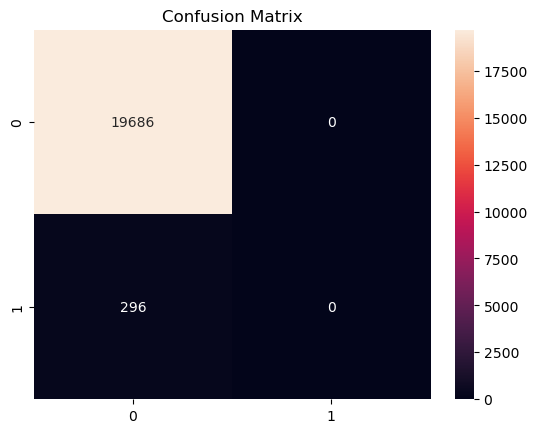

In [17]:
print("Confusion matrix:")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()